In [55]:
import re
import numpy as np
from pathlib import Path

FLOAT = False
expon = 23 if FLOAT else 53  // 53 bits in for exp (vs 52 for normals)

# Path to the header file
path = Path("ziggurat_const_float.h" if FLOAT else "ziggurat_constants.h")
text = path.read_text()

# --- helpers -------------------------------------------------------------

def parse_uint32_array(name, text):
    m = re.search(
        rf"static const uint32_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+", body)
    return np.array([int(v.rstrip("UL"), 16) for v in vals], dtype=np.uint32)


def parse_float_array(name, text):
    m = re.search(
        rf"static const float {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?", body)
    return np.array([v.rstrip("f") for v in vals], dtype=np.float32)


def parse_float_scalar(name, text):
    m = re.search(
        rf"static const float {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1).rstrip("f"))

def parse_uint64_array(name, text):
    m = re.search(
        rf"static const uint64_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    print('m=', m)
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+(?:[uUlL]+)?", body)
    return np.array([int(re.sub(r"[uUlL]+$", "", v), 16) for v in vals], dtype=np.uint64)

def parse_double_array(name, text):
    m = re.search(
        rf"static const double {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", body)
    return np.array(vals, dtype=np.float64)


def parse_double_scalar(name, text):
    m = re.search(
        rf"static const double {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1))


# --- parse everything ----------------------------------------------------

if FLOAT:
    ki = parse_uint32_array("ke_float", text)
    wi = parse_float_array("we_float", text)
    fi = parse_float_array("fe_float", text)
    r = parse_float_scalar("ziggurat_exp_r_f", text)
else:
    ki = parse_uint64_array("ke_double", text)
    wi = parse_double_array("we_double", text)
    fi = parse_double_array("fe_double", text)
    r = parse_double_scalar("ziggurat_exp_r", text)

# --- sanity prints -------------------------------------------------------

print("ki:", ki.shape, ki.dtype)
print("wi:", wi.shape, wi.dtype)
print("fi:", fi.shape, fi.dtype)
print("r =", r)

m= <re.Match object; span=(21708, 27210), match='static const uint64_t ke_double[] = {\n    0x001C>
ki: (256,) uint64
wi: (256,) float64
fi: (256,) float64
r = 7.69711747013105


In [58]:
xi = wi * 2**expon
xi[255], abs(r - xi[255])

(np.float64(7.69711747013105), np.float64(0.0))

In [59]:
import numpy as np
from numpy import exp
fi[1], exp(-xi[1])

(np.float64(0.9381436808621747), np.float64(0.9381436808621747))

In [65]:
len(ki),len(wi),len(fi)

(256, 256, 256)

In [66]:
import numpy as np

np.set_printoptions(precision=17, suppress=False)

def print_table(ki, wi, fi, n=3):
    idx1 = list(range(n));
    idx2 = list(range(len(ki)-n, len(ki)));
    print(f"{'i':>4} {'ki':>20} {'wi':>22} {'fi':>22}")
    print("-"*74)
    for i in idx1:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")
    print("  ...")
    for i in idx2:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")

print_table(ki, wi, fi)

   i                   ki                     wi                     fi
--------------------------------------------------------------------------
   0     7971545857431494 9.65574006320918298e-16 1.00000000000000000e+00
   1                    0 7.08901424395541433e-18 9.38143680862174700e-01
   2     5485857970336126 1.16394124966912238e-17 9.00469929925746482e-01
  ...
 253     8542525795804796 7.19244496608936156e-16 1.53629978030157236e-03
 254     8406823688997808 7.70609535003209675e-16 9.67269282327174536e-04
 255     8122426762520768 8.54551703858402742e-16 4.54134353841496765e-04


np.float32(5.9604645e-08)

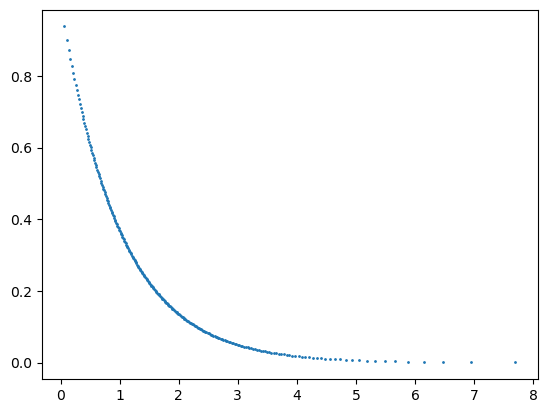

In [32]:
# Plot, and check fi
import matplotlib.pyplot as plt
plt.scatter(xi[1:], fi[1:], s=1)

yi = np.exp(-xi)
max(abs(fi[1:] - yi[1:]))

In [67]:
# Check ki:
kscaled = np.zeros(256)
kref = np.zeros(256)
kscaled[0] = ki[0]/2**expon
kscaled[1] = 0
kscaled[2:] = ki[2:]/2**expon
kref[0] = xi[255]/xi[0]
kref[1] = 0
kref[2:] = xi[1:-1]/xi[2:]
max(abs(kref - kscaled))

np.float64(3.3306690738754696e-16)

In [68]:
# check areas
from scipy.stats import norm
V = np.zeros(256)
V[1:] = (fi[:-1] - fi[1:])*xi[1:]
V[0] = fi[255]*r + np.exp(-r)
V[0]
max(V) - min(V)

np.float64(9.80118763926896e-17)

In [69]:
# Check secant + tangent areas
from numpy import exp
xi[0] = 0;
fd = -fi;
dy = -np.diff(fi)
dx = np.diff(xi)
A1 = -dy**2/fd[:-1]/2
A2 = -dx**2*fd[1:]/2
Atot = sum(dx*dy)
Asec = Atot/2
Atang = sum(A2)
Acurve = Atot - Atang - Asec

In [70]:
print(f"A1: {A1[0]:.6f}, {A1[1]:.6f}, total:{sum(A1):.6f}")
print(f"A2: {A2[0]:.6f}, {A2[1]:.6f}, total:{sum(A2):.6f}")
Atangent = sum(A2);
Asecant = Atot
print(f"A total: {Atot:.6f}")
print(f"Curve part:{Acurve:.6f} ({Acurve/Atot*100:.1f}%)")

A1: 0.001913, 0.000756, total:0.010713
A2: 0.001912, 0.000756, total:0.010702
A total: 0.022013
Curve part:0.000305 (1.4%)


In [71]:
dk = (1 << expon) - ki
slope = np.zeros(256);
slope[1:] = fi[1:]*wi[1:]/(fi[:-1] - fi[1:]);
slope

array([0.0000000000000000e+00, 1.0751551351916626e-16,
       2.7820274580458548e-16, 4.6194718656749172e-16,
       6.4979442156949700e-16, 8.3882401787711679e-16,
       1.0277964325774199e-15, 1.2161027694454571e-15,
       1.4034161896165175e-15, 1.5895515087164092e-15,
       1.7744007218025758e-15, 1.9579004478603915e-15,
       2.1400142692051322e-15, 2.3207226006623322e-15,
       2.5000166141088070e-15, 2.6778944620485213e-15,
       2.8543588607993156e-15, 3.0294155066260240e-15,
       3.2030720176029363e-15, 3.3753372158183006e-15,
       3.5462206347297719e-15, 3.7157321782552011e-15,
       3.8838818837542466e-15, 4.0506797571089579e-15,
       4.2161356584094362e-15, 4.3802592234898584e-15,
       4.5430598110512236e-15, 4.7045464681458118e-15,
       4.8647279088820185e-15, 5.0236125026606361e-15,
       5.1812082692731932e-15, 5.3375228789191464e-15,
       5.4925636557164076e-15, 5.6463375836619742e-15,
       5.7988513142677916e-15, 5.9501111753032332e-15,
       6.1